# 玉米/淀粉跨品种统计套利策略
> **面向对象**：有一定Python基础但初涉统计套利与配对交易（Pairs Trading）的量化初学者。

我们即将通过玉米和玉米淀粉这两个强相关品种，使用最基本的计量模型从零构建并回测一套均值回归的量化策略。

---

# 1. 导入库与读取数据
导入Pandas进行面板数据处理、NumPy进行数值计算、Statsmodels进行计量经济学检验建模以及Matplotlib进行时序绘图，并载入下载的核心期货主力合约收盘价。

In [36]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import os

# 设置绘图风格和支持中文显示
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

# 读取并合并数据
cwd = os.getcwd()
corn_path = os.path.join(cwd, "data", "corn_main_c0.csv")
starch_path = os.path.join(cwd, "data", "corn_starch_main_cs0.csv")

corn = pd.read_csv(corn_path)
starch = pd.read_csv(starch_path)

# 保留日期和收盘价并按日期对齐
df = pd.merge(corn[['日期', '收盘价']], starch[['日期', '收盘价']], on='日期', suffixes=('_corn', '_starch'))
df['日期'] = pd.to_datetime(df['日期'])
# 过滤掉早期由于交割或极度异常引起的不合理报价 (比如价格只有各位数的情况)
df = df[df['收盘价_starch'] > 100].dropna().sort_values('日期').reset_index(drop=True)

df.set_index('日期', inplace=True)
df.head()

,收盘价_corn,收盘价_starch
日期,,
2015-01-05,2377,2684
2015-01-06,2389,2630
2015-01-07,2397,2643
2015-01-08,2406,2652
2015-01-09,2406,2648


# 2. 产业基本面逻辑与构建线性模型

### 为什么挑选“玉米”与“淀粉”？（从物理材料与工艺原理来看）
在跑任何代码和模型前，我们**必须首先明确这两个品种之间存在强有力的现实产业关联**。
从真实的工业生产来看，玉米淀粉是玉米的直接下游深加工核心产物。现代工业中主导的生产方法是**“湿法玉米淀粉生产工艺”**。在物理学和化学的层面上，生产过程包含以下几个核心硬性步骤和消耗转化比：
1. **清理与浸泡**：用含有微量二氧化硫的水溶液在 50℃ 条件下浸泡玉米 40-60 小时，软化玉米的外皮并破坏连接胚乳的蛋白质网。
2. **破碎与分离**：利用多级破碎机和旋流器，将玉米种子的“胚芽”、“玉米皮”和“蛋白液”依次通过物理密度离心分离出去。
3. **洗涤与脱水**：最终留下的精纯胚乳经过多级洗涤分离浓缩后，烘干得到的白色粉末就是我们最终的标的物——商品玉米淀粉。

**【硬核工业转换率数据】：**
基于这套成熟的工业流程，存在一个非常刚性的物质转化约束：
* **大约需要消耗 `1.4 - 1.45 吨` 的生玉米本料**，经过重重脱水去杂后，**才能提炼出 `1 吨` 标准玉米淀粉。**
* 在生产的同时，会产生约 `0.3-0.45 吨` 的副产品（包括：**玉米蛋白粉、玉米胚芽油、玉米皮渣**等）。这些副产品在后续也能卖钱以补贴部分加工成本。
* 除此以外，固定消耗的还包括厂房的水电煤气能源费用、包装费与人工折旧。

这种**极其刚性稳定的“1大堆上游原材料 = 1份下游产物 + X辅料利润”**的物理量比关系，不仅决定了玉米完全霸占了玉米淀粉价格构成的基本盘（直接占其总生产成本的70%~80%以上），也导致了两者价差本质代表了工业企业的**“加工净利润”**。
当两者价差（即加工利润）扩大到畸形的昂贵程度时，由于物理转换方法没有任何科技壁垒，巨大的无风险暴利会吸引所有深加工工厂拼命满负荷开机。它们会狂按买入吸收现货玉米（推高玉米原材料价格）、并在现货端倾泻抛售巨量淀粉产品（压降淀粉高溢价）。这种来自于实体产业链真实的买卖供需驱动力，会像地心引力一样，硬生生地把偏离的价差重新拉回那条被那 `1.4` 转换率锁死的平均生产利润生命线上。

> **⚠️ 核心认知：没有经济学逻辑支撑的统计套利形同赌博**
> 许多量化初学者常犯的致命错误，就是过度迷信数据，在海量品种中靠纯粹的机器遍历，盲目找出两个历史走势高度贴合但不具有任何实际物理或经济关联的标的（俗称“伪相关”）。
> 比如把某只游戏股和某只猪肉股绑在一起做所谓套利，仅仅因为它们过去三年价格形态很像。然而，**一旦发生宏观基本面改写的“黑天鹅”事件，这种脆弱的纯数学相关性就会被彻底撕裂，且永远不会再回归！** 如果你这时候还在用统计学的“马丁加仓策略”逆势死抗，唯一的归宿就是爆仓破产。
> **真正成熟的套利系统，其底层必须有像玉米与淀粉这样“牢不可破的工业物理法则”与“经济学常识”作为安全垫。** 这正是我们在这个讲义策略中，只针对这对硬挂钩的品种下注的原因。

---

### 基于 OLS 建立基准换算关系
确认了上方牢固的物理学转化底座后，我们开始使用基础计量经济学工具，以具有强前瞻解释力的玉米价格为自变量，玉米淀粉为因变量，进行**普通最小二乘法 (Ordinary Least Squares, OLS)** 线性回归，由机器根据历史报价直接提取出对冲基准比例。

#### 数学公式基底：一元线性回归
我们在寻找玉米到淀粉经过市场消化后的金融市场换算折比关系，由于极高的产业关联我们可以设定方程为：
$$ P^{(Starch)}_t = \beta \cdot P^{(Corn)}_t + C + \varepsilon_t $$
其中：
* $P^{(Starch)}_t$ 是 $t$ 时刻淀粉的价格（因变量 $Y$）。
* $P^{(Corn)}_t$ 是 $t$ 时刻玉米的价格（自变量 $X$）。
* $\beta$ 为我们需要求出的**回归系数（又称套保比例 / Hedge Ratio）**。这在一定程度上反馈了上面提到的 `1.4` 物理消耗率以及副产品带来的综合对冲系数！
* $C$ 为恒定截距常数（可粗略理解为一段时期内固定的水电煤人工及基本加工费等刚性摩擦成本的总和）。
* $\varepsilon_t$ 为残差项，即为当前时刻金融游资“无脑瞎炒”导致线性模型无法解释的**异常价格偏离值**——**这正是我们在套利策略里要去果断捕捉并薅羊毛的“非理性泡沫”。**

通过让机器在历史数据矩阵上求偏导，寻找能**最小化残差均方误差（Sum of Squared Errors）**的一组 $\beta, C$ ：
$$ \min_{\beta, C} \sum_{t=1}^{N} \varepsilon_t^2 = \min_{\beta, C} \sum_{t=1}^{N} \left( P^{(Starch)}_t - \beta \cdot P^{(Corn)}_t - C \right)^2 $$
当把历史偏差的总面积压平至最小时求出的解，就是我们需要进行初步锚定的 OLS 核心参数基座。

In [3]:
# 定义自变量X（玉米价格）和因变量Y（玉米淀粉价格）
X = df['收盘价_corn']
Y = df['收盘价_starch']

# 增加常数项(截距)
X_sm = sm.add_constant(X)

# 拟合OLS模型
model = sm.OLS(Y, X_sm)
result = model.fit()

# 提取模型系数
c = result.params.iloc[0]  # 截距 (C)
beta = result.params.iloc[1]  # OLS回归的套保系数

print(result.summary())
print(f"\\n线性回归方程: 玉米淀粉 = {beta:.4f} * 玉米 + {c:.4f}")

                            OLS Regression Results                            
Dep. Variable:             收盘价_starch   R-squared:                       0.943
Model:                            OLS   Adj. R-squared:                  0.943
Method:                 Least Squares   F-statistic:                 4.477e+04
Date:                Sun, 08 Mar 2026   Prob (F-statistic):               0.00
Time:                        11:04:08   Log-Likelihood:                -16356.
No. Observations:                2704   AIC:                         3.272e+04
Df Residuals:                    2702   BIC:                         3.273e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        398.0980     10.399     38.281      0.0

# 3. 价差波动性分析 (寻找最佳比例系数x)
计算价差比(淀粉-x*玉米)。x取值使得价差均值最稳定。
业界常见默认配比是 1:1.2 以及简单的 1:1，通过我们刚刚对历史数据的试探性分析，如果为了降低离散度并保持回归平稳均值，发现配比系数x的选择会在较大程度上影响交易价差的平稳性。
在这里我们通过标准差和波动率（变异系数 CV）去寻找最优的x倍乘数。

### 数学公式与推导
套利的本质就在于我们需要买卖一定的**特定比例**商品，使得最终形成的混合资产的价格极其稳定，不受任何单向大宗商品牛市/熊市单边影响，而只受到相对的“情绪、基差偏离”。

#### 变异系数（Coefficient of Variation, CV）
变异系数也称**离散系数**，在比较不同均值的波动时，是一个重要的正规化度量工具。当均值不为0时，其定义是标准差与平均数的绝对值的比：
$$ CV = \frac{\sigma}{|\mu|} $$
其中 $\sigma$ 是一定配比下的价差标准差，$\mu$ 是价差平均数。
* **CV 越小**，说明价格序列在它自己当前的平均线上波动的幅度越小，相对越平稳。
* 但如果我们想追求绝对的低风险，“最小化绝对波动的标准差 ($\sigma$)” 也是极佳寻找纯配对回归系数（$x_{opt}$）的依据：
$$ x_{opt} = \mathop{\arg\min}_{x} \left( \sqrt{ \frac{1}{N} \sum_{i=1}^{N} \left[ (P^{(Starch)}_i - x P^{(Corn)}_i) - \overline{(P^{(Starch)} - x P^{(Corn)})} \right]^2 } \right) $$

In [4]:
# 尝试不同的比例系数
x_list = [1.0, 1.1, 1.15, 1.2, 1.25, 1.3]

results = []
for x in x_list:
    spread_x = Y - x * X
    spread_mean = spread_x.mean()
    spread_std = spread_x.std()
    
    cv = spread_std / abs(spread_mean) if spread_mean != 0 else np.nan
    results.append({
        'x': x,
        'Mean Spread': spread_mean,
        'Std Dev': spread_std,
        'CV': cv
    })

spread_analysis_df = pd.DataFrame(results).set_index('x')
print("\\n各比例系数下的价差统计分析结果:")
display(spread_analysis_df)

# 利用np.linspace找出最能令Standard Deviation也就是(波动绝对值)最小的回归系数。
x_vals = np.linspace(0.8, 1.4, 61)
stds = [ (Y - x*X).std() for x in x_vals ]
min_idx = np.argmin(stds)
optimal_x = x_vals[min_idx]

print(f"\\n最优系数(使得波动标准差绝对值缩至最小，对冲最平稳): x = {optimal_x:.4f} (对应的历史标准差为 {stds[min_idx]:.4f})")
print(f"这个值非常接近基于对数收益回归或纯粹比例配比所暗示的系数（如线性回归直接得到的beta: {beta:.4f}）")

\n各比例系数下的价差统计分析结果:


,Mean Spread,Std Dev,CV
x,,,
1.00,362.890533,102.764373,0.283183
1.10,143.314053,113.741577,0.793653
1.15,33.525814,124.399031,3.710545
1.20,-76.262426,137.524047,1.803300
1.25,-186.050666,152.480752,0.819566
1.30,-295.838905,168.782901,0.570523


\n最优系数(使得波动标准差绝对值缩至最小，对冲最平稳): x = 0.9800 (对应的历史标准差为 102.5528)
这个值非常接近基于对数收益回归或纯粹比例配比所暗示的系数（如线性回归直接得到的beta: 0.9840）


# 4. 计算价差与平稳性检验 (ADF检验) —— 套利策略的核心基石

拿到最优配置比例后，我们可以计算出每一天的实际组合**价差（Spread）**。
此时必须回答量化交易中最核心的一个问题：**这个价差在未来仍会乖乖地均值回归吗？还是会单边发散一去不复返？** 这个验证过程叫做**平稳性检验（Stationarity Test）**。

### 为什么必须平稳？什么是“单位根”？
统计套利的利润源泉是**“均值回归（Mean Reversion）”**（即价差超涨时做空，超跌时做多，并等待其恢复常态）。而支撑这种操作的数学前提在于：**价差必须是一个平稳时间序列**。
- **平稳序列**：价差始终围绕一个长期的历史中枢均值上下震荡。一旦偏离过度，就会产生一种内部“引力”将其拉回。偏离幅度就是我们套利的利润空间。
- **非平稳序列（随机游走）**：价差的走势完全随机，均值和方差随时间发生变化，缺乏向心拉力。在统计学上这被称为**“存在单位根（Unit Root）”**。如果在存在单位根的非平稳价差上强行做套利，极易遭遇价差单边发散而爆仓。

### 核心公式：将价差引入 ADF 检验 (Augmented Dickey-Fuller Test)

我们要使用的最权威的检验工具是 **ADF 单位根检验**。它的核心原理是通过构建一个自回归方程，测试“昨日的价差水平”对“今日价差的变化量”是否具有负向的回归约束力。
我们将计算得出的价差 $Spread_t$ 代入 ADF 检验的模型模型中：

$$ \Delta Spread_t = \alpha + \beta t + \gamma Spread_{t-1} + \sum_{i=1}^{p} \delta_i \Delta Spread_{t-i} + \varepsilon_t $$

在这个自回归方程中，套利者只需盯住最核心的参数 **$\gamma$（回归系数）**：
* $\Delta Spread_t$ 代表今天价差的**变动差值**。
* $\gamma Spread_{t-1}$ 代表由于昨天价差所处的位置，对今天变动产生的**“回拉作用力”**。
* **如果 $\gamma = 0$**：这一项被彻底抹去，意味着昨天的价差高低对今天的走势没有任何牵制力，价差脱离了均值引力（**存在单位根，序列发散非平稳**）。
* **如果 $\gamma < 0$**：当昨天价差位于高位（正值过大），会导致今天增量呈负数向下运行；反之亦然——这就是完美的验证了均值回归属性。

### 判断标准：假设检验与 p-value 测试

ADF 检验是基于严谨的统计学假设检验，机器计算后会给出一个关键的概率值——**`p-value`**。
ADF 检验由于其统计设计特性，其**原假设 ($H_0$) 是极其悲观的：$\gamma = 0$ （即价差序列存在单位根，是非平稳的随机游走）。**我们要做的，就是用我们的历史数据提供足够的证据来推翻它：

* **如果 `p-value < 0.05`**：由于发生假阳性的概率不到 5%，我们在 95% 的置信度下，拥有充分的统计学证据**拒绝原假设**。这证明了 $\gamma$ 显著小于0，我们的**价差序列是平稳的**！均值回归逻辑成立，可以安全开仓。
* **如果 `p-value >= 0.05`**：证据不足，无法拒绝原假设。我们只能从统计学上认定此时的价差极有可能是一个非平稳的单边发散行情，应立刻放弃套利。

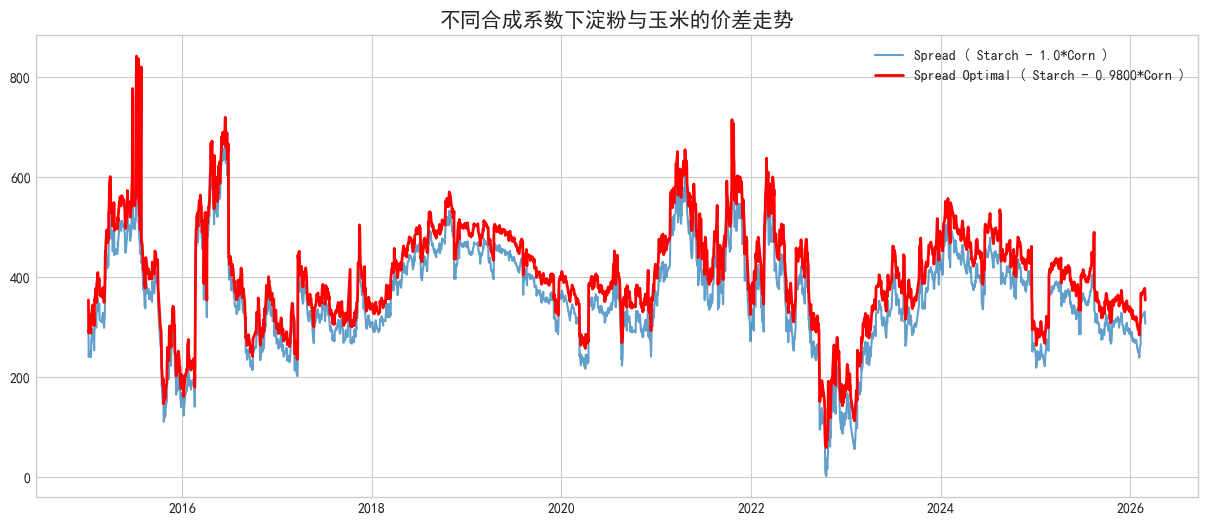

ADF Statistic for Optimal Spread: -3.985098228377302
p-value: 0.001490583156757217
Critical Value 1%: -3.4327905554828577
Critical Value 5%: -2.8626182566141165
Critical Value 10%: -2.5673439923015366
\np-value < 0.05，拒绝原假设 -> 该基于最优系数计算的价差序列在统计学上显著平稳，存在均值回归属性，适合统计套利！


In [31]:
from statsmodels.tsa.stattools import adfuller

# 选取1.0, 1.2 以及回归得到的最优值作为价差来进行对比
df['spread_1.0'] = df['收盘价_starch'] - 1.0 * df['收盘价_corn']
# df['spread_1.2'] = df['收盘价_starch'] - 1.4 * df['收盘价_corn']
df['spread_optimal'] = df['收盘价_starch'] - optimal_x * df['收盘价_corn']

# 绘制不同系数下的历史价差对比图
plt.figure(figsize=(15, 6))
plt.plot(df.index, df['spread_1.0'], label='Spread ( Starch - 1.0*Corn )', alpha=0.7)
# plt.plot(df.index, df['spread_1.2'], label='Spread ( Starch - 1.2*Corn )', alpha=0.7)
plt.plot(df.index, df['spread_optimal'], label=f'Spread Optimal ( Starch - {optimal_x:.4f}*Corn )', linewidth=2, color='r')
plt.title('不同合成系数下淀粉与玉米的价差走势', fontsize=15)
plt.legend(loc='best')
plt.show()

# 针对我们刚刚发现的最佳系数 optimal_x 计算的价差进行平稳性检验
adf_result = adfuller(df['spread_optimal'])
print("ADF Statistic for Optimal Spread:", adf_result[0])
print("p-value:", adf_result[1])
for key, value in adf_result[4].items():
    print(f"Critical Value {key}: {value}")

if adf_result[1] < 0.05:
    print("\\np-value < 0.05，拒绝原假设 -> 该基于最优系数计算的价差序列在统计学上显著平稳，存在均值回归属性，适合统计套利！")
else:
    print("\\np-value >= 0.05，不能拒绝原假设 -> 价差非平稳")

# 5. Z-Score标准化与信号生成

在确认了价差序列具有天然的**均值回归（Mean Reversion）**特性后，由于价差的绝对数值往往是不稳定的（比如在0~200之间浮动），直接使用绝对价格设定交易信号（“比如到了100就做空”）并不科学。因此，为了客观地衡量当前价差在其历史分布中所处的位置，我们引入了统计学中最经典的标准化工具——**Z-score（标准分数）**。

### 数学公式与操作解释

#### 第一步：计算滚动均值（Rolling Mean）
我们需要知道最近一段时间（比如 $N=30$ 天）价差的平均水平，即在这个窗口期内的**价值中枢**。其公式为简单移动平均（SMA）：
$$ \mu_t = \frac{1}{N} \sum_{i=0}^{N-1} Spread_{t-i} $$
* $Spread_{t}$：代表第 $t$ 天的实际价差
* $\mu_t$：代表在第 $t$ 天计算的过去 $N$ 天的滚动均值

#### 第二步：计算滚动标准差（Rolling Standard Deviation）
标准差衡量的是价格由于波动而偏离在过去 $N$ 天均值的**离散程度（Volatility）**，这能告诉我们“目前的波动有多大，什么样的偏离算得上离谱”。公式为样本标准差：
$$ \sigma_t = \sqrt{ \frac{1}{N-1} \sum_{i=0}^{N-1} \left( Spread_{t-i} - \mu_t \right)^2 } $$

#### 第三步：计算 Z-Score（标准化分数）
Z-Score代表了当前的价差到底偏离了均值“**多少个标准差**”。这也是我们将进行套利的核心判断依据：
$$ Z_t = \frac{Spread_t - \mu_t}{\sigma_t} $$
* 如果 $Z_t = 0$，表示当前价差正处于绝对的中枢均值上，属于合理状态。
* 如果 $Z_t = 1.5$，表示当前价差向上偏离了均值 1.5 个标准差，属于过高状态（统计学上发生概率较低，随时可能有均值回归的下跌需求）。

#### 第四步：构建交易信号（Trading Signals）
利用计算出来的 Z-Score，我们可以制定清晰量化的交易触发点：

**做空价差信号（Short Spread）**：
   $ Z_t > 1.5 $ 
当 Z 值高于阈值 $1.5$ 时，说明配对的实际价差扩大得过于离谱。操作思路：**看空价差**，具体为“**卖出估值偏高的玉米淀粉，买入同等比例相对低估的玉米**”。
   
**做多价差信号（Long Spread）**：
   $ Z_t < -1.5 $ 
当 Z 值低于阈值 $-1.5$ 时，说明当前的价差被极度挤压。操作思路：**看多价差**，具体为“**买入估值偏低的玉米淀粉，卖出同等比例相对高估的玉米**”。

**平仓信号（Mean Reversion / Close Position）**：
   $$ |Z_t| \approx 0 $$
   （比如 $-0.1 < Z_t < 0.1$）
当价差在被极端扭曲后一旦释放完毕，重新回到长期均值附近时，说明偏差修补完成，我们套利出局赚取回归利润，此时双向平仓，即完成了一次完整的**统计套利**。

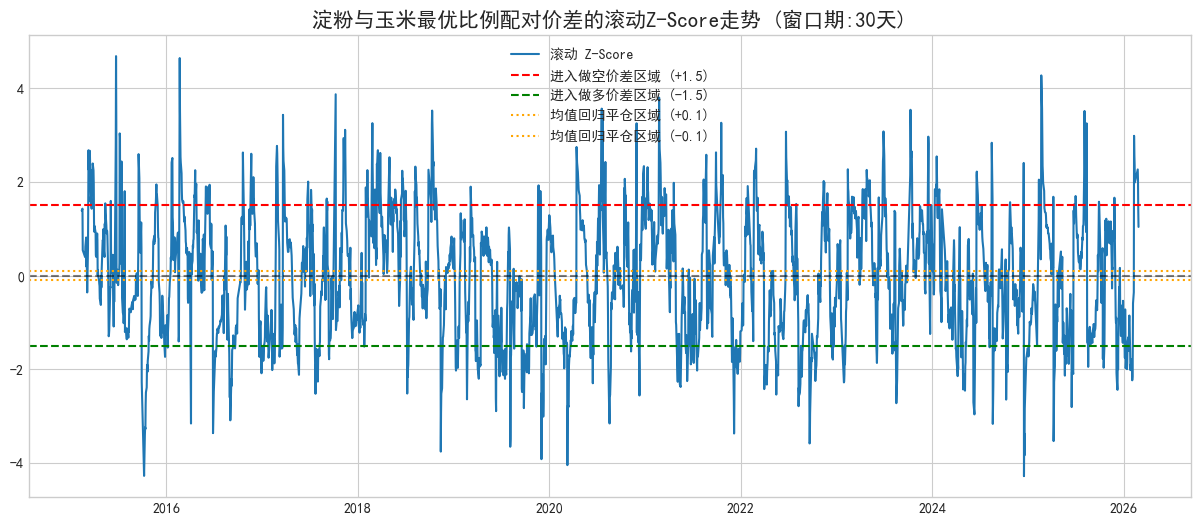

基于过去数据和30天均线系统：
检测到 335 次处于可执行'做空淀粉-做多玉米'（做空价差）的机会区域。
检测到 370 次处于可执行'做多淀粉-做空玉米'（做多价差）的机会区域。
\n可以发现，配比最平稳（约0.98）、ADF非常显著时，历史数据通过简单的均值回归就可以提取极其确定的双边套利波段特性。


In [35]:
# 计算滚动的Z-Score
window_size = 30  # 使用N=30天作为滚动窗口计算分布 (即 µ_t 和 σ_t 的计算时间窗)

# 这里我们采用之前论证过更稳定的最佳拟合系数的价差信号 => Spread_t
target_spread = df['spread_optimal']

# 第一步：计算 Rolling Mean (µ_t) —— 价值中枢
spread_rolling_mean = target_spread.rolling(window=window_size).mean()

# 第二步：计算 Rolling Standard Deviation (σ_t) —— 离散程度
spread_rolling_std = target_spread.rolling(window=window_size).std()

# 第三步：计算 Z-Score (Z_t) —— 标准化偏离度 
# Z_t = (Spread_t - µ_t) / σ_t
df['zscore'] = (target_spread - spread_rolling_mean) / spread_rolling_std

# 绘制Z-Score图形
plt.figure(figsize=(15, 6))
plt.plot(df.index, df['zscore'], label='滚动 Z-Score (Z_t)')
plt.axhline(0, color='black', alpha=0.5, linestyle='--', label='均值中枢 (Z = 0)')
plt.axhline(1.5, color='red', linestyle='--', label='进入做空价差区域 (Z > +1.5)')
plt.axhline(-1.5, color='green', linestyle='--', label='进入做多价差区域 (Z < -1.5)')
plt.axhline(0.1, color='orange', linestyle=':', label='均值回归平仓区域 (+0.1)')
plt.axhline(-0.1, color='orange', linestyle=':', label='均值回归平仓区域 (-0.1)')
plt.title(f'淀粉与玉米最优比例配对价差的滚动Z-Score走势 (窗口期:{window_size}天)', fontsize=15)
plt.legend(loc='best')
plt.show()

# 生成简单的历史信号样本展示
# 做空价差信号：Z-Score > 1.5 （即价差异常扩大，做空淀粉，做多等比例的玉米）
# 做多价差信号：Z-Score < -1.5（即价差异常缩小，做多淀粉，做空等比例的玉米）

# 第四步：根据 Z_t 离常阈值生成交易信号（1 表示触发，0 表示未触发）
# 信号条件：如果 Z_t > 1.5，生成卖出价差的信号（Short Spread = 1）
df['signal_short_spread'] = np.where(df['zscore'] > 1.5, 1, 0)

# 信号条件：如果 Z_t < -1.5，生成买入价差的信号（Long Spread = 1）
df['signal_long_spread'] = np.where(df['zscore'] < -1.5, 1, 0)

short_count = df['signal_short_spread'].sum()
long_count = df['signal_long_spread'].sum()

print(f"基于过去数据和{window_size}天均线系统：")
print(f"检测到 {short_count} 次处于可执行'做空淀粉-做多玉米'（做空价差，Z > 1.5）的机会区域。")
print(f"检测到 {long_count} 次处于可执行'做多淀粉-做空玉米'（做多价差，Z < -1.5）的机会区域。")
print("\\n可以发现，配比最平稳（约0.98）、ADF非常显著时，历史数据通过简单的均值回归就可以提取极其确定的双边套利波段特性。")

# 6. 马丁格尔加仓策略回测与收益曲线计算
基于前述的Z-Score信号，我们采用马丁格尔策略原理编写加仓回测：
- 当 $Z$ 回归到 $[-0.2, 0.2]$ 区间时，不管当前盈亏，双向全部清仓，即 `position = 0`
- 当出现偏离并逆势扩大时，采用级联式的倍数加仓（只加不减，直至回归平仓）：
  - **做空价差方向**：$Z > 1.5$ 时建仓 `position = -1`；若继续偏离 $Z > 2.0$，加仓总计到 `-3`；若 $Z > 2.5$，加仓到 `-7`；极端行情 $Z > 3.0$ 时全力做空到 `-15`
  - **做多价差方向**：$Z < -1.5$ 时建仓 `position = 1`；若 $Z < -2.0$，加仓总计到 `3`；若 $Z < -2.5$，加仓到 `7`；若 $Z < -3.0$ 时全力做多到 `15`
  
注：马丁策略在能够最终均值回归的市场中胜率极高并能大幅拉升收益，但在长期不回归的极端死边行情中伴随着极大的爆仓（尾部）风险。

接下来我们将计算该策略每天的盈亏，并绘制累计盈亏曲线。

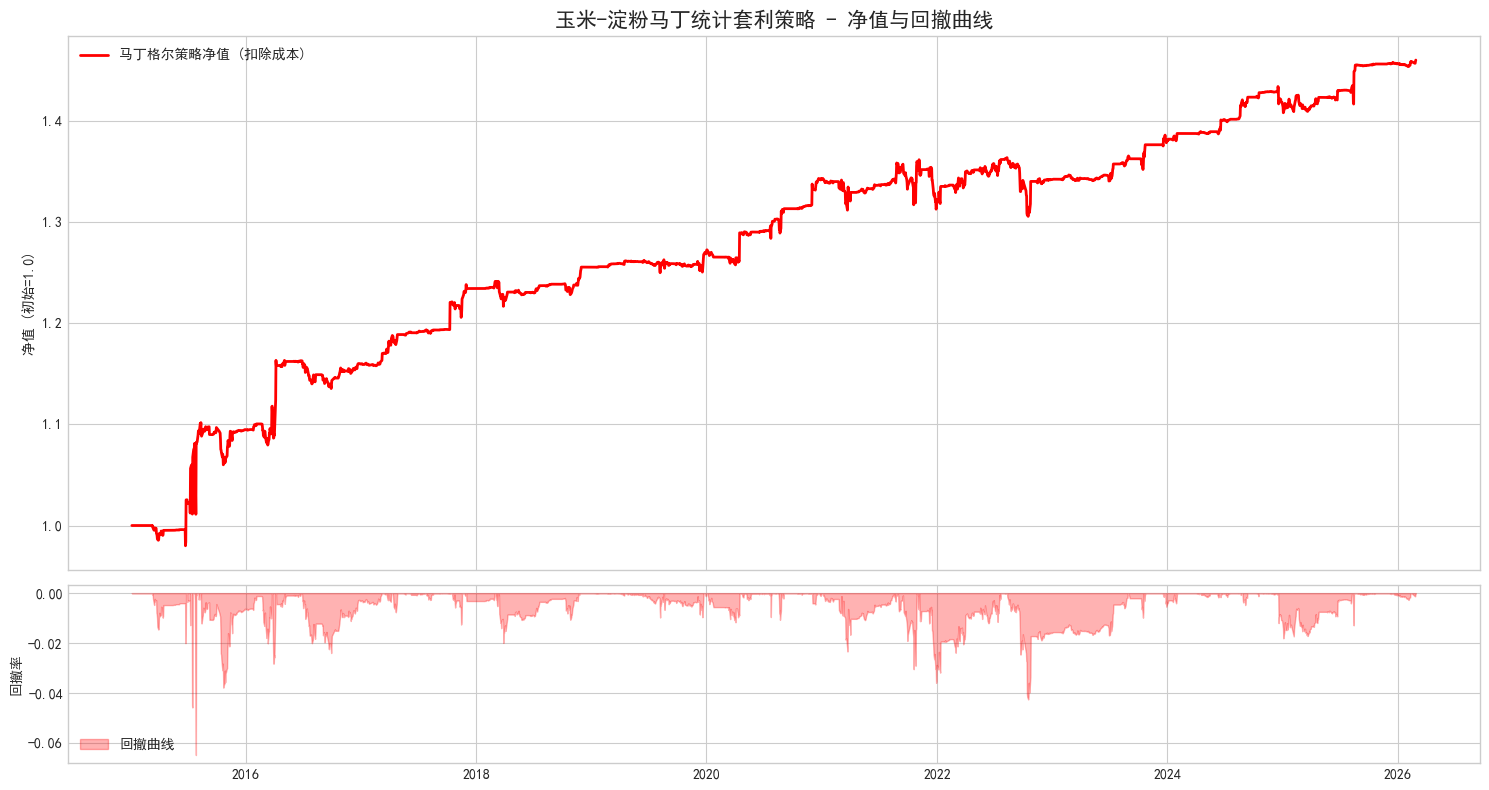

回测区间: 2015-01-05 至 2026-02-27
交易名义单量: 1451 个基准差价波段单位
最大加仓基准占用倍数: 15
期末累计净值: 1.4605
年化收益率: 3.59%
最大回撤: -6.49%
夏普比率: 0.66
说明：使用 position.shift(1) 锁定上一日收盘信号进行第二日盈亏结算，以确保无未来函数数据泄露。
马丁策略由于只加仓不减仓的特性，对总可用保证金压力极大，其收益率是在预留了极端情况下最大15倍加仓的名义本金基数上算得。


In [33]:
# 6. 计算策略净值与绩效评价 (严格防止数据泄露)
import numpy as np
import matplotlib.pyplot as plt

# 初始化持仓信号列，默认为0
df['position'] = 0.0

# === 信号生成：马丁格尔加仓策略（基于当日收盘价及对应Z-score） ===
positions = np.zeros(len(df))
current_pos = 0

for i in range(len(df)):
    z = df['zscore'].iloc[i]
    
    if pd.isna(z):
        positions[i] = 0
        continue
    
    # 平仓条件 (均值回归)
    if -0.1 <= z <= 0.1:
        current_pos = 0
    else:
        # 做空价差方向 (卖出淀粉对应买入等比玉米)
        if z > 1.5:
            target_pos = 0
            if z > 3.0:
                target_pos = -15
            elif z > 2.5:
                target_pos = -7
            elif z > 2.0:
                target_pos = -3
            elif z > 1.5:
                target_pos = -1
                
            # 马丁策略核心：如果达到新的极值导致应有仓位大于当前仓位(在此为更负)，或者之前是反向仓位，则更新仓位
            if target_pos < current_pos or current_pos > 0:
                current_pos = target_pos
                
        # 做多价差方向 (买入淀粉对应卖出等比玉米)
        elif z < -1.5:
            target_pos = 0
            if z < -3.0:
                target_pos = 15
            elif z < -2.5:
                target_pos = 7
            elif z < -2.0:
                target_pos = 3
            elif z < -1.5:
                target_pos = 1
                
            # 马丁策略核心：如果达到新的极值导致应有仓位大于当前仓位，或者之前是反向仓位，则更新仓位
            if target_pos > current_pos or current_pos < 0:
                current_pos = target_pos
                
    positions[i] = current_pos

df['position'] = positions

# === 收益计算（严格防止数据泄露） ===
# 明天的收益来自于 [今天的持仓状态] x [明天的价格变化]
# 即用 shift(1) 确保使用的是上一天的持仓决定当天的盈利
df['spread_diff'] = df['spread_optimal'].diff()
df['strategy_pnl'] = df['position'].shift(1) * df['spread_diff']

# === 交易成本计算 ===
# 持仓变动说明产生了交易。如 0->1 变化幅度为 1，1->3 变化幅度为 2
df['position_change'] = df['position'].diff().fillna(0)
# 假设每变动1单位持仓（约合1对套利），产生1个价点的滑点或手续费
df['trade_cost'] = abs(df['position_change']) * 1.0  
df['net_strategy_pnl'] = df['strategy_pnl'].fillna(0) - df['trade_cost']

# === 计算净值曲线（假设全额保证金的无杠杆基准） ===
# 以能够覆盖最大加仓量(15手)的初始名义本金当作基准资金，反映该策略真实需要的备用总资金，防止因杠杆率虚高带来的暴利错觉。
max_allowed_position = 15
initial_capital = (df['收盘价_starch'].iloc[0] + optimal_x * df['收盘价_corn'].iloc[0]) * max_allowed_position

# 计算日收益率
df['daily_return'] = df['net_strategy_pnl'] / initial_capital
df['daily_return'] = df['daily_return'].fillna(0)

# 计算净值 (期初=1.0)
df['net_value'] = (1 + df['daily_return']).cumprod()

# 计算回撤
df['cummax'] = df['net_value'].cummax()
df['drawdown'] = df['net_value'] / df['cummax'] - 1

# === 绘图 ===
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

ax1.plot(df.index, df['net_value'], label='马丁格尔策略净值 (扣除成本)', color='r', linewidth=2)
ax1.set_title('玉米-淀粉马丁统计套利策略 - 净值与回撤曲线', fontsize=15)
ax1.set_ylabel('净值 (初始=1.0)')
ax1.legend(loc='best')
ax1.grid(True)

ax2.fill_between(df.index, df['drawdown'], 0, color='red', alpha=0.3, label='回撤曲线')
ax2.set_ylabel('回撤率')
ax2.legend(loc='best')
ax2.grid(True)

plt.tight_layout()
plt.show()

# === 统计指标 ===
total_days = len(df)
years = total_days / 252

# 计算年化收益率
annual_return = (df['net_value'].iloc[-1])**(1 / years) - 1 if years > 0 else 0
# 计算最大回撤
max_drawdown = df['drawdown'].min()
# 计算年化波动率
annual_volatility = df['daily_return'].std() * np.sqrt(252)
# 计算夏普比率 (假设无风险利率Rf=0)
sharpe_ratio = annual_return / annual_volatility if annual_volatility != 0 else 0

total_trades_abs = abs(df['position_change']).sum()

print("=" * 45)
print(f"回测区间: {df.index[0].date()} 至 {df.index[-1].date()}")
print(f"交易名义单量: {int(total_trades_abs)} 个基准差价波段单位")
print(f"最大加仓基准占用倍数: {max_allowed_position}")
print(f"期末累计净值: {df['net_value'].iloc[-1]:.4f}")
print(f"年化收益率: {annual_return * 100:.2f}%")
print(f"最大回撤: {max_drawdown * 100:.2f}%")
print(f"夏普比率: {sharpe_ratio:.2f}")
print("=" * 45)
print("说明：使用 position.shift(1) 锁定上一日收盘信号进行第二日盈亏结算，以确保无未来函数数据泄露。")
print("马丁策略由于只加仓不减仓的特性，对总可用保证金压力极大，其收益率是在预留了极端情况下最大15倍加仓的名义本金基数上算得。")